<a href="https://colab.research.google.com/github/krxecs/traffic-prediction/blob/conv-to-pyg/stgcn_traffic_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# METR-LA traffic-speed forecasting with STGCN(Cheb)

This self-contained Colab notebook implements **STGCN(Cheb)** from Yu, Yin & Zhu (arXiv:1709.04875). It uses the METR-LA road graph from `adj_METR-LA.pkl`, `torch_geometric.nn.ChebConv` for Chebyshev graph convolution, and GLU-gated temporal convolution. It has no recurrent LSTM component.

## 1. Colab imports, reproducibility, and configuration

The first code cell clones this repository into Colab and makes its datasets and future Python modules available.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/krxecs/traffic-prediction.git"
COLAB_REPO_DIR = Path("/content/traffic-prediction")

try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    if (COLAB_REPO_DIR / ".git").is_dir():
        PROJECT_ROOT = COLAB_REPO_DIR
        print(f"Using existing repository checkout: {PROJECT_ROOT}")
    elif COLAB_REPO_DIR.exists():
        raise RuntimeError(
            f"{COLAB_REPO_DIR} exists but is not a Git checkout; choose another path or remove it."
        )
    else:
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(COLAB_REPO_DIR)],
            check=True,
        )
        PROJECT_ROOT = COLAB_REPO_DIR

else:
    PROJECT_ROOT = Path.cwd().resolve()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "torch-geometric"],
        check=True,
    )

print(f"Repository root: {PROJECT_ROOT}")
print(f"Repository imports enabled: {str(PROJECT_ROOT) in sys.path}")

Repository root: /content/traffic-prediction
Repository imports enabled: True


In [2]:
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch_geometric.nn import ChebConv
from torch.utils import data
from tqdm.auto import trange

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# These paths resolve from the repository checkout configured above.
DATA_DIR = Path("datasets/metr-la")
# Final comparison artifact: results/model_comparison.csv
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_TRAINING = True
NUM_SENSORS = 207
HORIZON_STEPS = (3, 6, 12)
STGCN_HISTORY_STEPS = 12
DAILY_OFFSET_STEPS = 288
WEEKLY_OFFSET_STEPS = 7 * DAILY_OFFSET_STEPS
PERIODIC_RADIUS = 6
STGCN_BATCH_SIZE = 50
MAX_EPOCHS = 50
# Classification metrics treat an observed speed below this cutoff as the positive class.
LOW_SPEED_THRESHOLD_MPH = 40.0
STGCN_DROPOUT = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print(f"Selected device: {DEVICE}")
print(f"DATA_DIR: {DATA_DIR}")
print(
    f"STGCN(PyG ChebConv): blocks=[[1, 32, 64], [64, 32, 128]], Ks=3, Kt=3, dropout={STGCN_DROPOUT}, RMSProp lr=0.001."
)

Selected device: cuda
DATA_DIR: datasets/metr-la
STGCN(PyG ChebConv): blocks=[[1, 32, 64], [64, 32, 128]], Ks=3, Kt=3, dropout=0.1, RMSProp lr=0.001.


## 2. METR-LA and graph loading, sensor alignment, causal missing-value handling, chronological split, and training-only normalization

In [3]:
def _as_sensor_key(value):
    """Match HDF5 columns and adjacency IDs despite bytes/int/string representation."""
    if isinstance(value, bytes):
        value = value.decode()
    return str(value)


def load_adjacency(path: Path):
    with path.open("rb") as handle:
        obj = pickle.load(handle, encoding="latin1")
    if isinstance(obj, (tuple, list)) and len(obj) >= 3:
        sensor_ids, sensor_id_to_ind, adjacency = obj[:3]
    elif isinstance(obj, dict):
        sensor_ids = obj.get("sensor_ids") or obj.get("sensors")
        sensor_id_to_ind = obj.get("sensor_id_to_ind") or obj.get("sensor_id_to_index")
        adjacency = obj.get("adj_mx") if "adj_mx" in obj else obj.get("adjacency")
    else:
        raise ValueError(
            "adj_METR-LA.pkl is not a supported tuple/list or dict-like METR-LA graph."
        )
    if sensor_ids is None or sensor_id_to_ind is None or adjacency is None:
        raise ValueError(
            "adj_METR-LA.pkl must provide sensor_ids, sensor_id_to_ind, and adjacency."
        )
    sensor_ids = list(sensor_ids)
    adjacency = np.asarray(adjacency, dtype=np.float32)
    return sensor_ids, sensor_id_to_ind, adjacency


def read_metr_la_hdf(path: Path):
    """Read standard METR-LA HDF5, including legacy pandas frequency metadata."""
    try:
        return pd.read_hdf(path)
    except TypeError as exc:
        # Some pandas/PyTables combinations reject legacy numpy.bytes_ frequency metadata.
        try:
            import tables
        except ImportError as import_exc:
            raise RuntimeError(
                "Could not read METR-LA.h5; install the standard Colab PyTables dependency."
            ) from import_exc
        try:
            with tables.open_file(path) as handle:
                values = handle.get_node("/df/block0_values").read()
                columns = handle.get_node("/df/block0_items").read()
                timestamps_ns = handle.get_node("/df/axis1").read()
            columns = [_as_sensor_key(column) for column in columns]
            return pd.DataFrame(
                values, index=pd.to_datetime(timestamps_ns), columns=columns
            )
        except Exception as fallback_exc:
            raise RuntimeError(
                f"Unable to read METR-LA HDF5 at {path}: {fallback_exc}"
            ) from exc


data_path = DATA_DIR / "METR-LA.h5"
adj_path = DATA_DIR / "adj_METR-LA.pkl"
if not data_path.is_file():
    raise FileNotFoundError(
        f"METR-LA.h5 is required at {data_path}. Set DATA_DIR to the Kaggle dataset directory."
    )
if not adj_path.is_file():
    raise FileNotFoundError(
        f"STGCN(Cheb) is enabled but adj_METR-LA.pkl is missing at {adj_path}."
    )

speed_frame = read_metr_la_hdf(data_path)
if not isinstance(speed_frame.index, pd.DatetimeIndex):
    speed_frame.index = pd.DatetimeIndex(speed_frame.index)
speed_frame = speed_frame.sort_index()
if speed_frame.shape[1] != NUM_SENSORS:
    raise ValueError(
        f"Expected {NUM_SENSORS} METR-LA sensors, found {speed_frame.shape[1]}."
    )
sensor_ids, sensor_id_to_ind, adjacency = load_adjacency(adj_path)
if len(sensor_ids) != NUM_SENSORS or adjacency.shape != (NUM_SENSORS, NUM_SENSORS):
    raise ValueError(
        f"Expected 207 sensors and (207, 207) adjacency; got {len(sensor_ids)} and {adjacency.shape}."
    )
mapping_by_key = {
    _as_sensor_key(key): int(value) for key, value in sensor_id_to_ind.items()
}
if set(mapping_by_key) != {
    _as_sensor_key(sensor_id) for sensor_id in sensor_ids
} or sorted(mapping_by_key.values()) != list(range(NUM_SENSORS)):
    raise ValueError(
        "sensor_id_to_ind must be a one-to-one mapping onto graph adjacency positions 0..206."
    )
# The adjacency tensor is indexed by sensor_id_to_ind, so put traffic columns into that exact order.
sensor_ids = [
    next(sensor_id for sensor_id in sensor_ids if _as_sensor_key(sensor_id) == key)
    for key, _ in sorted(mapping_by_key.items(), key=lambda pair: pair[1])
]

column_by_key = {_as_sensor_key(c): c for c in speed_frame.columns}
ordered_columns = []
for sensor_id in sensor_ids:
    key = _as_sensor_key(sensor_id)
    if key not in column_by_key:
        raise ValueError(
            f"Graph sensor ID {sensor_id!r} is absent from METR-LA.h5 columns."
        )
    ordered_columns.append(column_by_key[key])
reordering_required = list(speed_frame.columns) != ordered_columns
speed_frame = speed_frame.loc[:, ordered_columns].astype(np.float32)
if speed_frame.shape[1] != NUM_SENSORS or not np.isfinite(adjacency).all():
    raise ValueError("METR-LA sensor/adjacency validation failed.")
print("METR-LA alignment validation")
print(f"  data shape: {speed_frame.shape}")
print(f"  timestamp range: {speed_frame.index.min()} to {speed_frame.index.max()}")
print(f"  sensors: {speed_frame.shape[1]}")
print(f"  adjacency shape: {adjacency.shape}")
print(f"  reordered HDF5 columns to graph sensor order: {reordering_required}")

raw_speed = speed_frame.to_numpy(dtype=np.float32).copy()
observed_mask = np.isfinite(raw_speed) & (raw_speed > 0.0)
raw_speed[~observed_mask] = np.nan
n_total = len(raw_speed)
train_end, val_end = int(0.70 * n_total), int(0.80 * n_total)
if not (0 < train_end < val_end < n_total):
    raise ValueError("Chronological 70/10/20 split could not be constructed.")


def causal_forward_fill(values):
    """Fill only from past values; leading unavailable readings stay NaN."""
    filled = values.copy()
    for t in range(1, len(filled)):
        missing = ~np.isfinite(filled[t])
        filled[t, missing] = filled[t - 1, missing]
    return filled


causal_speed = causal_forward_fill(raw_speed)
train_observed = observed_mask[:train_end]
train_values = causal_speed[:train_end]
train_mean = float(np.nanmean(train_values[train_observed]))
train_std = float(np.nanstd(train_values[train_observed]))
if not np.isfinite(train_mean) or not np.isfinite(train_std) or train_std <= 0:
    raise ValueError("Training-only Z-score statistics are invalid.")
normalized_speed = (causal_speed - train_mean) / train_std
print(
    f"Chronological split: train=[0,{train_end}), val=[{train_end},{val_end}), test=[{val_end},{n_total})"
)
print(f"Training-only Z-score mean={train_mean:.4f}, std={train_std:.4f}")

METR-LA alignment validation
  data shape: (34272, 207)
  timestamp range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
  sensors: 207
  adjacency shape: (207, 207)
  reordered HDF5 columns to graph sensor order: False
Chronological split: train=[0,23990), val=[23990,27417), test=[27417,34272)
Training-only Z-score mean=58.5842, std=12.8229


## 3. Leakage-safe STGCN windows and metrics

F1-score and accuracy use the 40 mph low-speed cutoff as the positive class. ROC AUC uses continuous negative predicted speed, so it measures ranking quality without thresholding the prediction score.

In [4]:
class STGCNForecastDataset(data.Dataset):
    def __init__(self, normalized, observed, target_range, history, horizon):
        self.normalized, self.observed, self.history, self.horizon = (
            normalized,
            observed,
            history,
            horizon,
        )
        candidates = []
        for target in range(target_range.start, target_range.stop):
            origin = target - horizon
            recent = slice(origin - history + 1, origin + 1)
            if recent.start >= 0 and np.isfinite(normalized[recent]).all():
                candidates.append(target)
        if not candidates:
            raise ValueError(
                "No valid STGCN windows were created; check causal missing-value availability."
            )
        self.targets = np.asarray(candidates, dtype=np.int64)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        target = int(self.targets[index])
        origin = target - self.horizon
        return {
            "recent": torch.from_numpy(
                self.normalized[origin - self.history + 1 : origin + 1].astype(
                    np.float32
                )
            ),
            "target": torch.from_numpy(
                np.nan_to_num(self.normalized[target], nan=0.0).astype(np.float32)
            ),
            "mask": torch.from_numpy(self.observed[target].astype(np.float32)),
        }


def make_loader(split, horizon, batch_size, shuffle):
    ranges = {
        "train": range(0, train_end),
        "val": range(train_end, val_end),
        "test": range(val_end, n_total),
    }
    ds = STGCNForecastDataset(
        normalized_speed, observed_mask, ranges[split], STGCN_HISTORY_STEPS, horizon
    )
    return data.DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=PIN_MEMORY
    ), ds


def masked_mse(prediction, target, mask):
    return ((prediction - target).square() * mask).sum() / mask.sum().clamp_min(1.0)


def binary_roc_auc(target_positive, positive_score):
    target_positive = np.asarray(target_positive, dtype=bool)
    positive_score = np.asarray(positive_score, dtype=np.float64)
    positive_count = int(target_positive.sum())
    negative_count = int((~target_positive).sum())
    if positive_count == 0 or negative_count == 0:
        return np.nan

    order = np.argsort(positive_score, kind="mergesort")
    sorted_score = positive_score[order]
    boundaries = np.r_[0, np.flatnonzero(np.diff(sorted_score)) + 1, len(sorted_score)]
    sorted_ranks = np.empty(len(sorted_score), dtype=np.float64)
    for start, stop in zip(boundaries[:-1], boundaries[1:]):
        sorted_ranks[start:stop] = (start + 1 + stop) / 2.0
    ranks = np.empty_like(sorted_ranks)
    ranks[order] = sorted_ranks
    rank_sum = ranks[target_positive].sum()
    return float(
        (rank_sum - positive_count * (positive_count + 1) / 2.0)
        / (positive_count * negative_count)
    )


def original_unit_metrics(prediction, target, mask):
    prediction = prediction * train_std + train_mean
    target = target * train_std + train_mean
    valid = (
        mask.astype(bool) & np.isfinite(prediction) & np.isfinite(target) & (target > 0)
    )
    if not valid.any():
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "F1-score": np.nan,
            "ROC AUC": np.nan,
            "Accuracy": np.nan,
        }
    error = prediction[valid] - target[valid]
    target_positive = target[valid] < LOW_SPEED_THRESHOLD_MPH
    prediction_positive = prediction[valid] < LOW_SPEED_THRESHOLD_MPH
    true_positive = np.logical_and(target_positive, prediction_positive).sum()
    false_positive = np.logical_and(~target_positive, prediction_positive).sum()
    false_negative = np.logical_and(target_positive, ~prediction_positive).sum()
    f1_denominator = 2 * true_positive + false_positive + false_negative
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error**2))),
        "MAPE": float(np.mean(np.abs(error) / target[valid]) * 100.0),
        "F1-score": float(2 * true_positive / f1_denominator)
        if f1_denominator
        else 0.0,
        "ROC AUC": binary_roc_auc(target_positive, -prediction[valid]),
        "Accuracy": float(np.mean(target_positive == prediction_positive)),
    }

## 4. STGCN(Cheb) graph preprocessing, model definition, and identity verification

In [5]:
def pyg_graph_from_adjacency(adjacency_matrix):
    asymmetric = not np.allclose(adjacency_matrix, adjacency_matrix.T, atol=1e-6)
    graph = (
        np.maximum(adjacency_matrix, adjacency_matrix.T)
        if asymmetric
        else adjacency_matrix.copy()
    )
    np.fill_diagonal(graph, 0.0)
    rows, columns = np.nonzero(graph)
    print(
        f"Adjacency asymmetric: {asymmetric}; spectral symmetrization applied: {asymmetric}"
    )
    return (
        torch.from_numpy(np.stack((rows, columns))).long(),
        torch.from_numpy(graph[rows, columns]).float(),
    )


class TemporalConvLayer(nn.Module):
    def __init__(self, c_in, c_out, kt=3):
        super().__init__()
        self.conv = nn.Conv2d(c_in, 2 * c_out, kernel_size=(kt, 1))

    def forward(self, x):
        linear, gate = self.conv(x).chunk(2, dim=1)
        return linear * torch.sigmoid(gate)  # GLU semantics


class PyGChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, ks, edge_index, edge_weight):
        super().__init__()
        self.register_buffer("edge_index", edge_index)
        self.register_buffer("edge_weight", edge_weight)
        self.conv = ChebConv(c_in, c_out, K=ks, normalization="sym")

    def forward(self, x):
        batch_size, channels, steps, nodes = x.shape
        node_features = x.permute(0, 2, 3, 1).reshape(
            batch_size * steps, nodes, channels
        )
        convolved = self.conv(node_features, self.edge_index, self.edge_weight)
        return convolved.reshape(batch_size, steps, nodes, -1).permute(0, 3, 1, 2)


class STConvBlock(nn.Module):
    def __init__(self, c_in, c_mid, c_out, edge_index, edge_weight, kt=3, dropout=0.1):
        super().__init__()
        self.temporal1 = TemporalConvLayer(c_in, c_mid, kt)
        self.graph = PyGChebGraphConv(c_mid, c_mid, 3, edge_index, edge_weight)
        self.dropout = nn.Dropout(dropout)
        self.temporal2 = TemporalConvLayer(c_mid, c_out, kt)
        self.residual = (
            nn.Conv2d(c_in, c_out, kernel_size=1) if c_in != c_out else nn.Identity()
        )
        self.c_out = c_out
        self.nodes = int(edge_index.max()) + 1

    def forward(self, x):
        y = self.temporal1(x)
        y = self.graph(y)
        y = torch.relu(y)
        y = self.dropout(y)
        y = self.temporal2(y)
        residual = self.residual(x)[:, :, -y.shape[2] :, :]
        y = y + residual
        y = y.permute(0, 2, 1, 3)
        y = torch.nn.functional.layer_norm(y, (self.c_out, self.nodes))
        return y.permute(0, 2, 1, 3)


class STGCN(nn.Module):
    def __init__(self, edge_index, edge_weight, dropout=STGCN_DROPOUT):
        super().__init__()
        self.blocks = nn.ModuleList(
            [
                STConvBlock(1, 32, 64, edge_index, edge_weight, dropout=dropout),
                STConvBlock(64, 32, 128, edge_index, edge_weight, dropout=dropout),
            ]
        )
        self.output_temporal = TemporalConvLayer(128, 128, 3)
        self.output = nn.Conv2d(128, 1, kernel_size=(2, 1))

    def forward(self, recent):
        x = recent.unsqueeze(1)
        for block in self.blocks:
            x = block(x)
        x = self.output_temporal(x)
        return self.output(x).squeeze(1).squeeze(1)


PYG_EDGE_INDEX, PYG_EDGE_WEIGHT = pyg_graph_from_adjacency(adjacency)


def verify_stgcn():
    model = STGCN(PYG_EDGE_INDEX, PYG_EDGE_WEIGHT)
    assert PYG_EDGE_INDEX.shape[0] == 2
    assert PYG_EDGE_WEIGHT.shape == (PYG_EDGE_INDEX.shape[1],)
    assert len(model.blocks) == 2
    assert all(block.dropout.p == STGCN_DROPOUT for block in model.blocks)
    with torch.no_grad():
        output = model(torch.zeros(2, STGCN_HISTORY_STEPS, NUM_SENSORS))
    assert output.shape == (2, NUM_SENSORS) and torch.isfinite(output).all()
    print(
        f"model name: STGCN(PyG ChebConv)\nhistory: 12\nblocks: [[1,32,64],[64,32,128]]\nKs: 3\nKt: 3\ntemporal gate: GLU\ngraph convolution: torch_geometric.nn.ChebConv\ndropout: {STGCN_DROPOUT} after graph activation\nPyG edges: {PYG_EDGE_INDEX.shape[1]}\noptimizer: RMSProp\nLR: 0.001\nLR gamma: 0.7\nLR interval: 5 epochs\nbatch size: 50\nepochs: 50\nadjacency used by model: YES"
    )
    return model


_ = verify_stgcn()

Adjacency asymmetric: True; spectral symmetrization applied: True
model name: STGCN(PyG ChebConv)
history: 12
blocks: [[1,32,64],[64,32,128]]
Ks: 3
Kt: 3
temporal gate: GLU
graph convolution: torch_geometric.nn.ChebConv
dropout: 0.1 after graph activation
PyG edges: 2626
optimizer: RMSProp
LR: 0.001
LR gamma: 0.7
LR interval: 5 epochs
batch size: 50
epochs: 50
adjacency used by model: YES


## 5. STGCN(Cheb) training

In [6]:
def move_batch(batch):
    return {
        key: value.to(DEVICE, non_blocking=PIN_MEMORY) for key, value in batch.items()
    }


def evaluate_model(model, loader):
    model.eval()
    losses = []
    predictions = []
    targets = []
    masks = []
    with torch.no_grad():
        for batch in loader:
            batch = move_batch(batch)
            pred = model(batch["recent"])
            loss = masked_mse(pred, batch["target"], batch["mask"])
            if not torch.isfinite(loss):
                raise FloatingPointError("STGCN(Cheb) produced a non-finite loss.")
            losses.append(loss.item())
            predictions.append(pred.cpu().numpy())
            targets.append(batch["target"].cpu().numpy())
            masks.append(batch["mask"].cpu().numpy())
    return (
        float(np.mean(losses)),
        np.concatenate(predictions),
        np.concatenate(targets),
        np.concatenate(masks),
    )


def train_stgcn(horizon):
    train_loader, _ = make_loader("train", horizon, STGCN_BATCH_SIZE, True)
    val_loader, _ = make_loader("val", horizon, STGCN_BATCH_SIZE, False)
    model = STGCN(PYG_EDGE_INDEX, PYG_EDGE_WEIGHT).to(DEVICE)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)
    train_curve = []
    val_curve = []
    epoch_bar = trange(1, 51, desc=f"STGCN(Cheb) h={horizon}", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        epoch_losses = []
        for batch in train_loader:
            batch = move_batch(batch)
            optimizer.zero_grad(set_to_none=True)
            pred = model(batch["recent"])
            loss = masked_mse(pred, batch["target"], batch["mask"])
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "STGCN(Cheb) produced a non-finite training loss."
                )
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        val_loss, *_ = evaluate_model(model, val_loader)
        train_curve.append(float(np.mean(epoch_losses)))
        val_curve.append(val_loss)
        epoch_bar.set_postfix(
            lr=f"{optimizer.param_groups[0]['lr']:.6g}",
            train=f"{train_curve[-1]:.5f}",
            val=f"{val_loss:.5f}",
        )
        scheduler.step()
    checkpoint = RESULTS_DIR / f"stgcn_h{horizon}_epoch50.pth"
    torch.save(
        {
            "model": model.state_dict(),
            "horizon": horizon,
            "epochs": 50,
            "mean": train_mean,
            "std": train_std,
        },
        checkpoint,
    )
    return model, train_curve, val_curve


stgcn_runs = {}
if RUN_TRAINING:
    for horizon in HORIZON_STEPS:
        stgcn_runs[horizon] = train_stgcn(horizon)

STGCN(Cheb) h=3:   0%|          | 0/50 [00:00<?, ?epoch/s]

STGCN(Cheb) h=6:   0%|          | 0/50 [00:00<?, ?epoch/s]

STGCN(Cheb) h=12:   0%|          | 0/50 [00:00<?, ?epoch/s]

## 6. STGCN(Cheb) held-out evaluation and visualizations

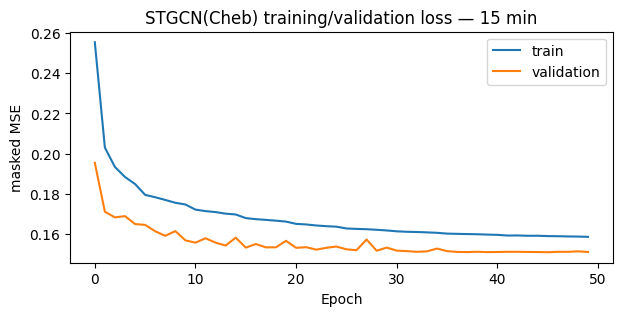

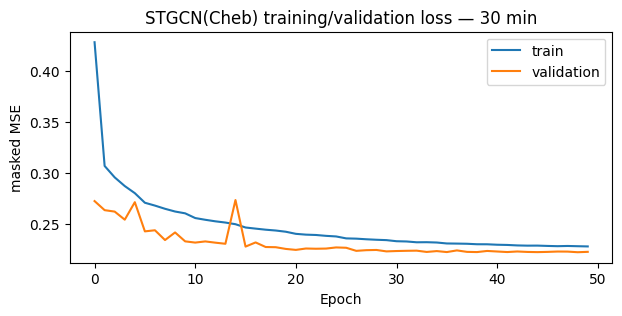

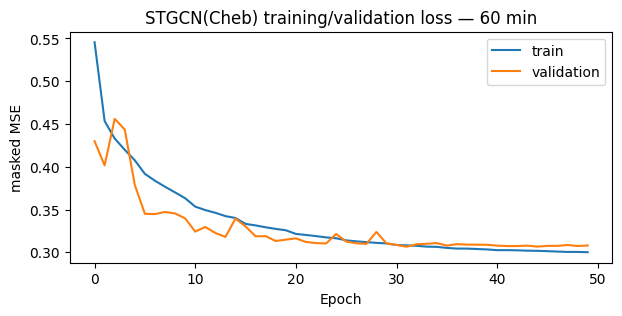

,Model,Horizon,MAE,RMSE,MAPE,F1-score,ROC AUC,Accuracy
0,STGCN(Cheb),15 min,3.008260,5.419577,7.865972,0.849266,0.978443,0.963796
1,STGCN(Cheb),30 min,3.612699,6.556292,9.985757,0.795018,0.963988,0.952457
2,STGCN(Cheb),60 min,4.403384,7.801915,12.609218,0.729080,0.944533,0.939418


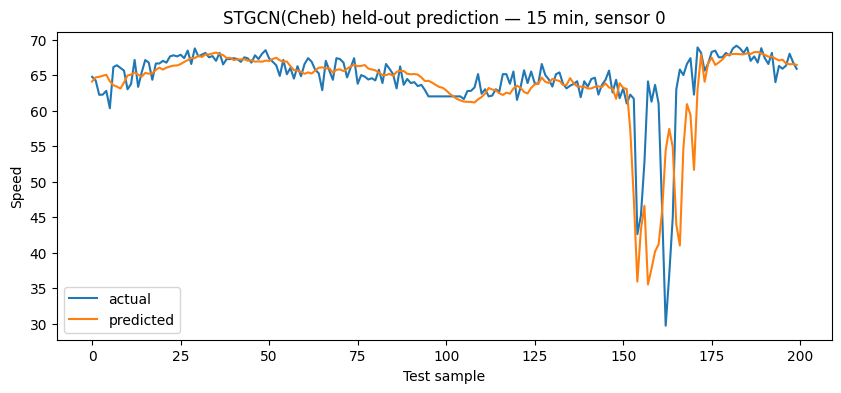

Saved results/stgcn_model_comparison.csv


In [7]:
if RUN_TRAINING:
    records = []
    representative = None
    for horizon, (model, train_curve, val_curve) in stgcn_runs.items():
        test_loader, _ = make_loader("test", horizon, STGCN_BATCH_SIZE, False)
        _, pred, target, mask = evaluate_model(model, test_loader)
        metric = original_unit_metrics(pred, target, mask)
        records.append(
            {"Model": "STGCN(Cheb)", "Horizon": f"{horizon * 5} min", **metric}
        )
        if representative is None:
            representative = (pred, target, mask, horizon)
        plt.figure(figsize=(7, 3))
        plt.plot(train_curve, label="train")
        plt.plot(val_curve, label="validation")
        plt.title(f"STGCN(Cheb) training/validation loss — {horizon * 5} min")
        plt.xlabel("Epoch")
        plt.ylabel("masked MSE")
        plt.legend()
        plt.show()
    comparison = pd.DataFrame(
        records,
        columns=[
            "Model",
            "Horizon",
            "MAE",
            "RMSE",
            "MAPE",
            "F1-score",
            "ROC AUC",
            "Accuracy",
        ],
    )
    display(comparison)
    comparison.to_csv(RESULTS_DIR / "stgcn_model_comparison.csv", index=False)
    pred, target, mask, horizon = representative
    sensor = int(np.flatnonzero(mask[0])[0])
    plt.figure(figsize=(10, 4))
    plt.plot(target[:200, sensor] * train_std + train_mean, label="actual")
    plt.plot(pred[:200, sensor] * train_std + train_mean, label="predicted")
    plt.title(f"STGCN(Cheb) held-out prediction — {horizon * 5} min, sensor {sensor}")
    plt.xlabel("Test sample")
    plt.ylabel("Speed")
    plt.legend()
    plt.show()
    print(f"Saved {RESULTS_DIR / 'stgcn_model_comparison.csv'}")
else:
    print(
        "RUN_TRAINING=False: set it to True to train STGCN(Cheb) at all three horizons."
    )